# Weather Trend Forecasting and Climate Analysis

## PM Accelerator Mission
PM Accelerator empowers future AI professionals through hands-on product development and real-world AI collaboration.

## Project Objective
The objective of this project is to analyze global weather trends, perform exploratory data analysis, build forecasting models, detect anomalies, and uncover environmental insights using machine learning and data science techniques.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import IsolationForest

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/GlobalWeatherRepository.csv")

In [3]:
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [4]:
df.shape

(142873, 41)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142873 entries, 0 to 142872
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       142873 non-null  object 
 1   location_name                 142873 non-null  object 
 2   latitude                      142873 non-null  float64
 3   longitude                     142873 non-null  float64
 4   timezone                      142873 non-null  object 
 5   last_updated_epoch            142873 non-null  int64  
 6   last_updated                  142873 non-null  object 
 7   temperature_celsius           142873 non-null  float64
 8   temperature_fahrenheit        142873 non-null  float64
 9   condition_text                142873 non-null  object 
 10  wind_mph                      142873 non-null  float64
 11  wind_kph                      142873 non-null  float64
 12  wind_degree                   142873 non-nul

In [6]:
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,142873.000000,142873.000000,1.428730e+05,142873.000000,142873.000000,142873.000000,142873.000000,142873.000000,142873.000000,142873.000000,...,142873.000000,142873.000000,142873.000000,142873.000000,142873.000000,142873.000000,142873.000000,142873.000000,142873.000000,142873.000000
mean,19.218836,21.932631,1.747646e+09,21.240901,70.235401,7.984150,12.852964,168.969896,1014.034765,29.943849,...,18.186393,450.100546,57.587410,14.815471,10.121830,23.855663,47.787123,1.686820,2.577296,49.557166
std,24.412007,65.782081,1.835379e+07,9.630392,17.334584,7.118168,11.452261,103.669463,10.177937,0.300498,...,13.676987,743.721540,30.424014,23.333692,34.793317,36.279451,147.514152,0.933964,2.423891,35.088214
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,1.731833e+09,15.500000,60.000000,3.800000,6.100000,80.000000,1010.000000,29.830000,...,10.200000,195.850000,38.000000,1.789000,1.110000,7.030000,9.805000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.747645e+09,23.700000,74.700000,6.700000,10.800000,161.000000,1013.000000,29.930000,...,15.300000,287.100000,55.000000,5.735000,2.405000,13.900000,19.610000,1.000000,2.000000,49.000000
75%,40.400000,49.882200,1.763451e+09,28.000000,82.300000,11.000000,17.600000,256.000000,1018.000000,30.060000,...,24.100000,451.400000,73.000000,17.050000,8.140000,27.380000,40.885000,2.000000,3.000000,84.000000
max,64.150000,179.220000,1.779431e+09,79.300000,174.700000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [7]:
df.isnull().sum().sort_values(ascending=False)

country                         0
feels_like_fahrenheit           0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Nitrogen_dioxide    0
air_quality_Sulphur_dioxide     0
air_quality_PM2.5               0
air_quality_PM10                0
air_quality_us-epa-index        0
air_quality_gb-defra-index      0
sunrise                         0
sunset                          0
moonrise                        0
moonset                         0
moon_phase                      0
visibility_km                   0
feels_like_celsius              0
location_name                   0
cloud                           0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fa

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df['last_updated'] = pd.to_datetime(df['last_updated'])

In [10]:
df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['day'] = df['last_updated'].dt.day

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142873 entries, 0 to 142872
Data columns (total 44 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   country                       142873 non-null  object        
 1   location_name                 142873 non-null  object        
 2   latitude                      142873 non-null  float64       
 3   longitude                     142873 non-null  float64       
 4   timezone                      142873 non-null  object        
 5   last_updated_epoch            142873 non-null  int64         
 6   last_updated                  142873 non-null  datetime64[ns]
 7   temperature_celsius           142873 non-null  float64       
 8   temperature_fahrenheit        142873 non-null  float64       
 9   condition_text                142873 non-null  object        
 10  wind_mph                      142873 non-null  float64       
 11  wind_kph     

# Exploratory Data Analysis (EDA)

This section explores weather trends, precipitation patterns, environmental conditions, and correlations between weather variables.

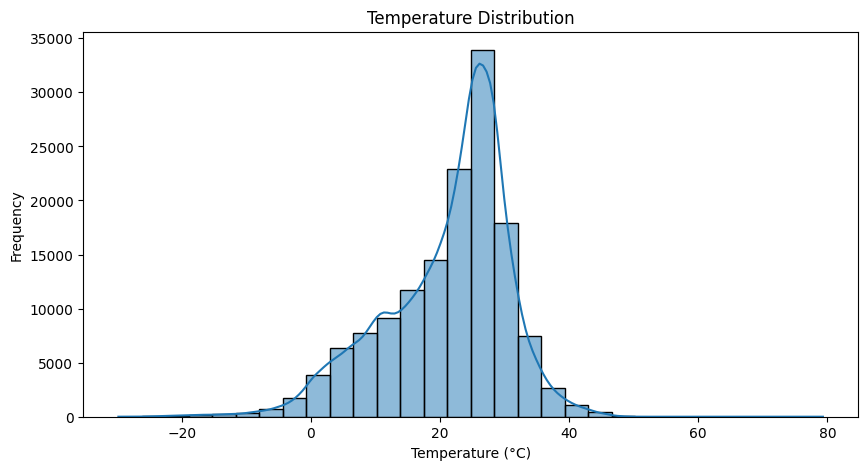

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['temperature_celsius'],
    kde=True,
    bins=30
)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.savefig("../images/temperature_distribution.png")

plt.show()

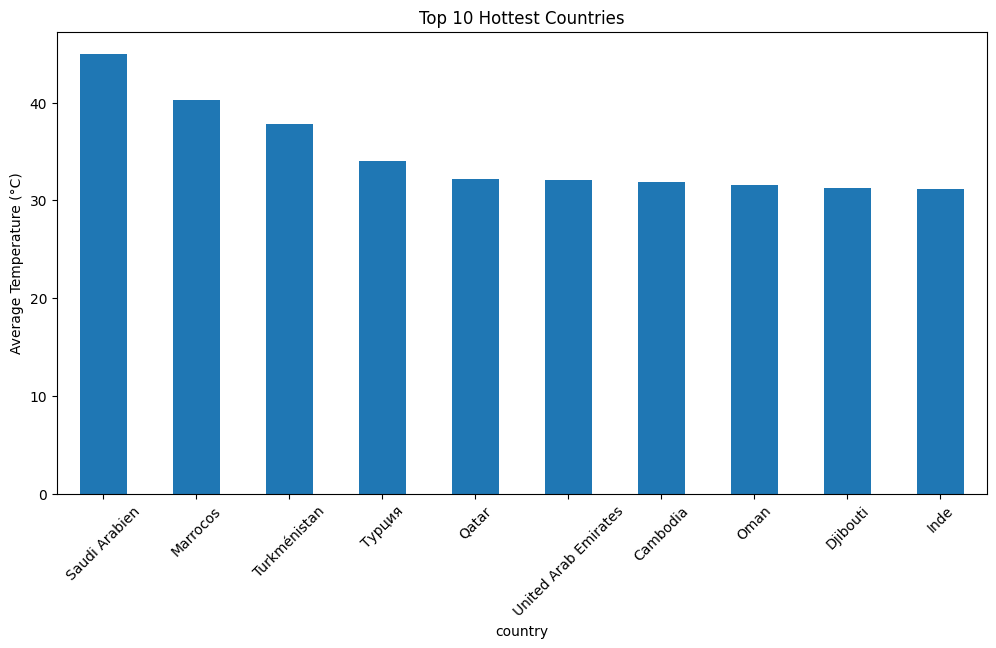

In [13]:
top_temp = (
    df.groupby('country')['temperature_celsius']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_temp.plot(kind='bar')

plt.title("Top 10 Hottest Countries")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=45)
plt.savefig("../images/hottest_countries.png")

plt.show()

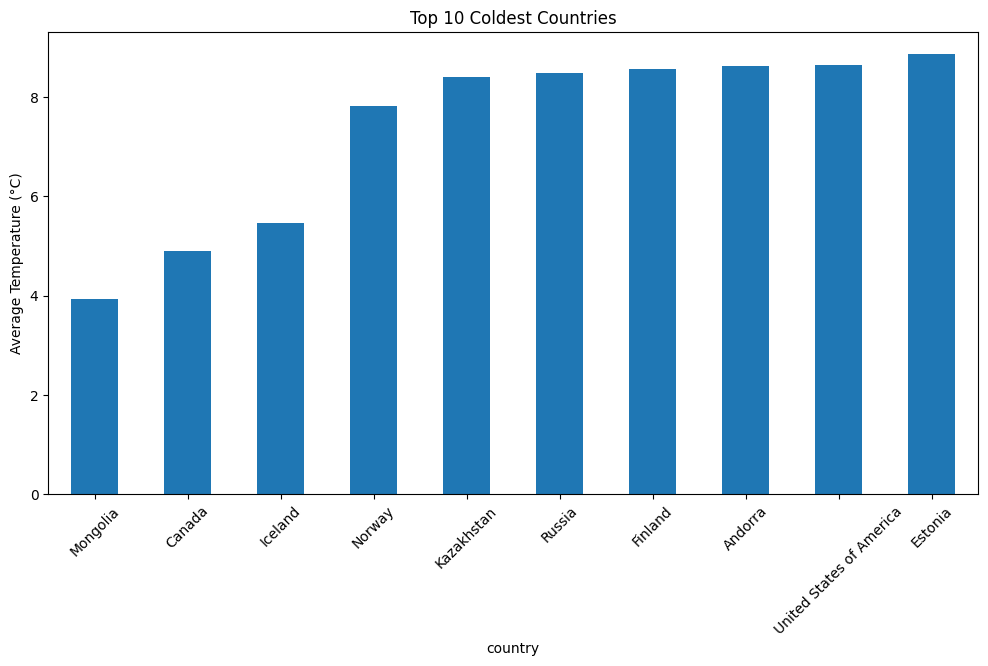

In [14]:
cold_temp = (
    df.groupby('country')['temperature_celsius']
    .mean()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(12,6))

cold_temp.plot(kind='bar')

plt.title("Top 10 Coldest Countries")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=45)
plt.savefig("../images/coldest_countries.png")

plt.show()

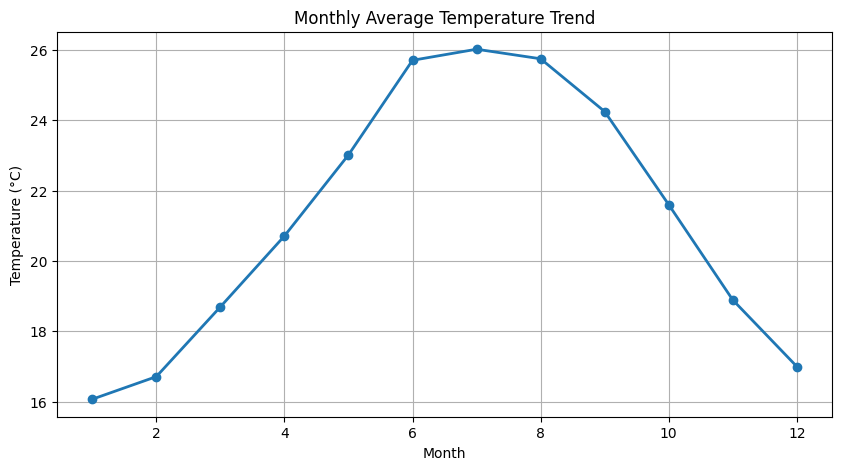

In [15]:
monthly_temp = (
    df.groupby('month')['temperature_celsius']
    .mean()
)

plt.figure(figsize=(10,5))

monthly_temp.plot(
    marker='o',
    linewidth=2
)

plt.title("Monthly Average Temperature Trend")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")

plt.grid(True)
plt.savefig("../images/monthly_trend.png")


plt.show()

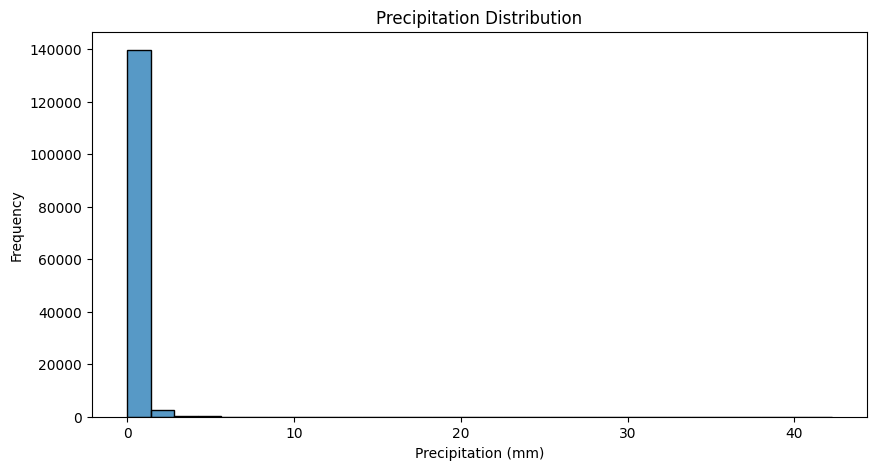

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['precip_mm'],
    bins=30
)

plt.title("Precipitation Distribution")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")
plt.savefig("../images/precipitation.png")


plt.show()

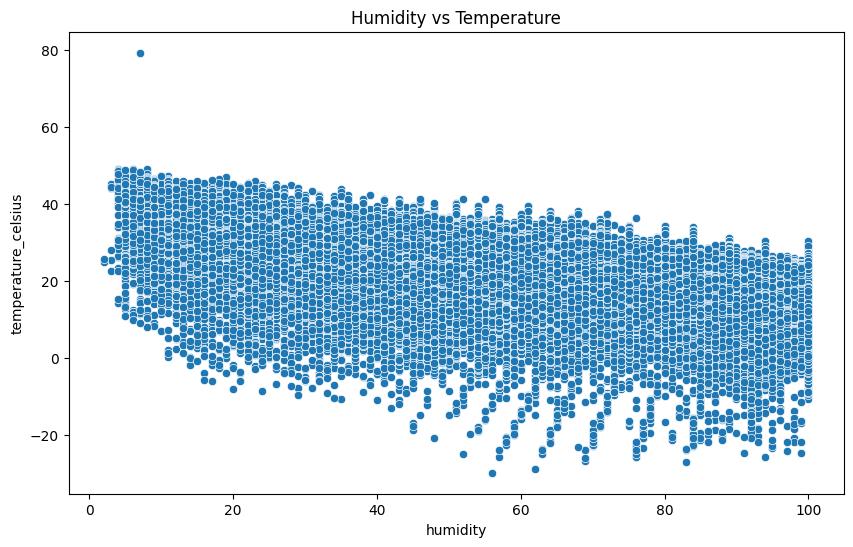

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='humidity',
    y='temperature_celsius',
    data=df
)

plt.title("Humidity vs Temperature")
plt.savefig("../images/humidity_vs_temperature.png")


plt.show()

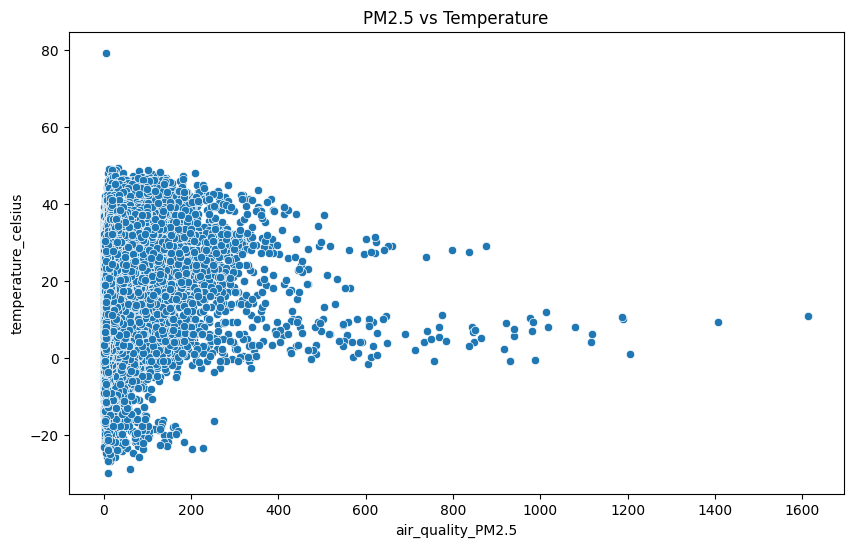

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='air_quality_PM2.5',
    y='temperature_celsius',
    data=df
)

plt.title("PM2.5 vs Temperature")
plt.savefig("../images/PM2.5_vs_temperature.png")


plt.show()

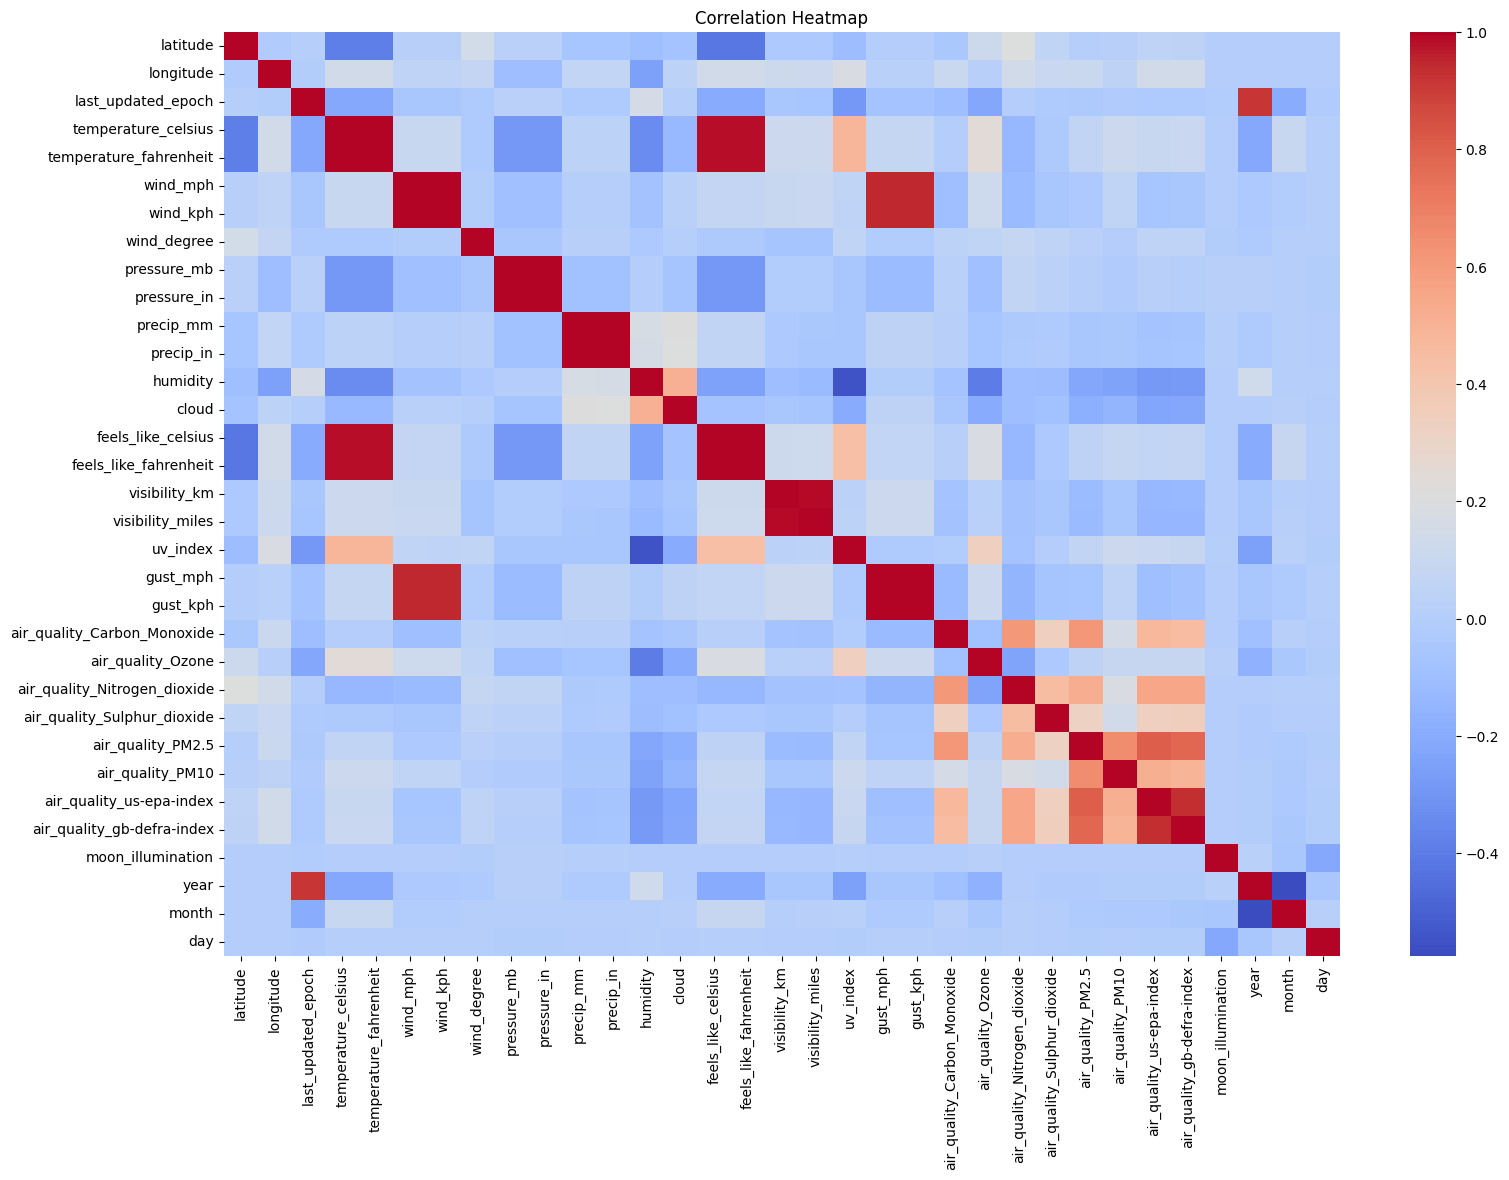

In [19]:
plt.figure(figsize=(18,12))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.savefig("../images/correlation_heatmap.png")


plt.show()

# Forecasting Models

This section builds and compares multiple machine learning models to forecast weather trends.

In [20]:
features = [
    'humidity',
    'wind_kph',
    'pressure_mb',
    'precip_mm',
    'air_quality_PM2.5',
    'cloud',
    'feels_like_celsius'
]

X = df[features]

y = df['temperature_celsius']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [24]:
print("Linear Regression Results")
print("-" * 40)

print("MAE:", mean_absolute_error(y_test, lr_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2 Score:", r2_score(y_test, lr_pred))

Linear Regression Results
----------------------------------------
MAE: 1.0237358501159282
RMSE: 1.4033819062097628
R2 Score: 0.9789483245842102


To balance computational efficiency and model performance, Random Forest hyperparameters were optimized using limited tree depth and reduced estimators.

In [25]:
import time

rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

start = time.time()

rf.fit(X_train, y_train)

end = time.time()

print("Training Time:", end - start)

rf_pred = rf.predict(X_test)

Training Time: 9.854758024215698


In [26]:
print("Random Forest Results")
print("-" * 40)

print("MAE:", mean_absolute_error(y_test, rf_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest Results
----------------------------------------
MAE: 0.2805848283443479
RMSE: 0.5310613922726829
R2 Score: 0.9969854368992969


In [27]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [28]:
print("XGBoost Results")
print("-" * 40)

print("MAE:", mean_absolute_error(y_test, xgb_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))

print("R2 Score:", r2_score(y_test, xgb_pred))

XGBoost Results
----------------------------------------
MAE: 0.29470604433943565
RMSE: 0.5524893688388949
R2 Score: 0.9967372577201584


In [29]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],

    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],

    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],

    'R2 Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.023736,1.403382,0.978948
1,Random Forest,0.280585,0.531061,0.996985
2,XGBoost,0.294706,0.552489,0.996737


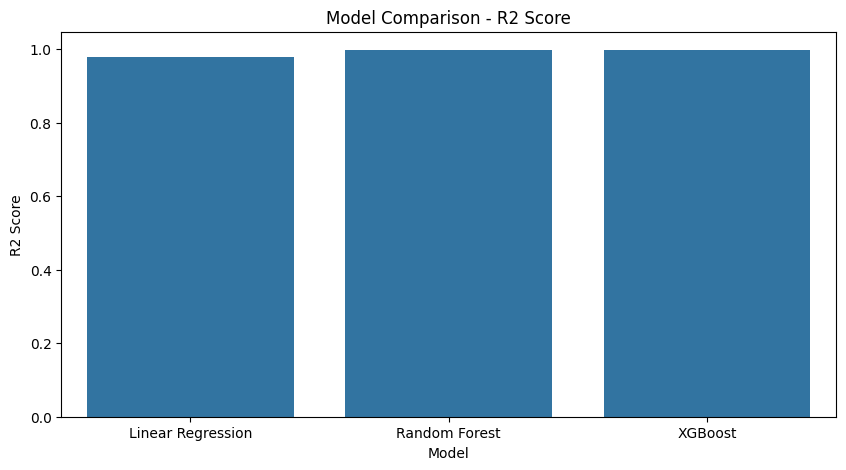

In [30]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results
)

plt.title("Model Comparison - R2 Score")
plt.savefig("../images/model_comparison.png")

plt.show()

# Feature Importance Analysis

This section identifies the most influential features affecting temperature prediction.

In [31]:
importance = pd.Series(
    rf.feature_importances_,
    index=features
)

importance = importance.sort_values()

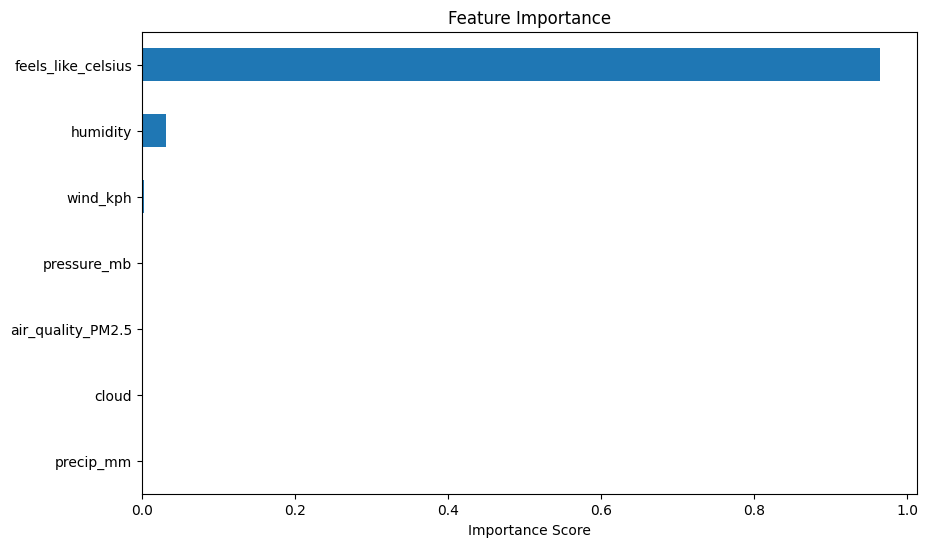

In [32]:
plt.figure(figsize=(10,6))

importance.plot(kind='barh')

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.savefig("../images/feature_importance.png")

plt.show()

# Anomaly Detection

Isolation Forest is used to detect unusual weather patterns and extreme temperature observations.

In [33]:
iso = IsolationForest(
    contamination=0.01,
    random_state=42
)

df['anomaly'] = iso.fit_predict(
    df[['temperature_celsius']]
)

In [34]:
df['anomaly'].value_counts()

anomaly
 1    141494
-1      1379
Name: count, dtype: int64

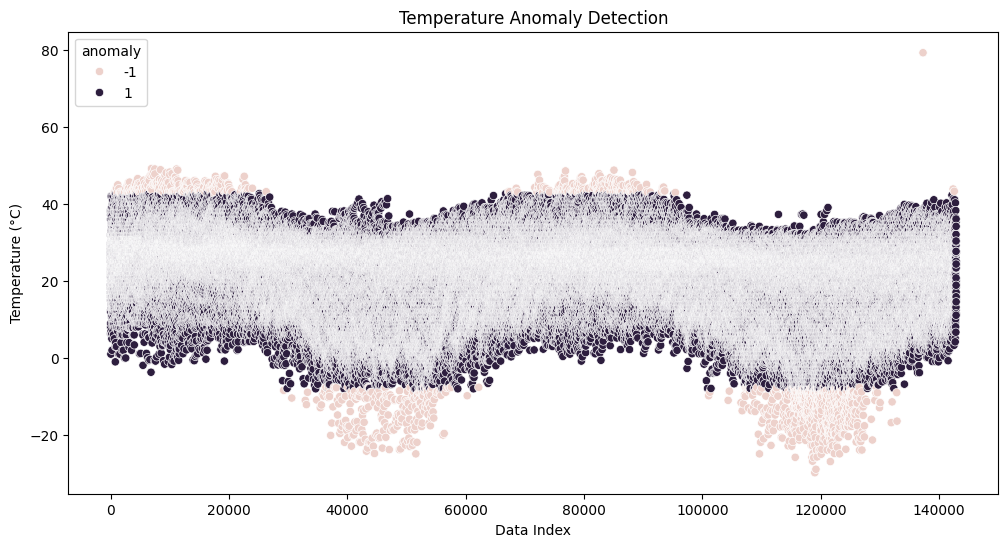

In [40]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    x=df.index,
    y='temperature_celsius',
    hue='anomaly',
    data=df
)

plt.title("Temperature Anomaly Detection")

plt.xlabel("Data Index")

plt.ylabel("Temperature (°C)")

plt.savefig("../images/anomaly_detection.png")

plt.show()

# Climate Pattern Analysis

This section analyzes long-term temperature patterns across countries and regions.

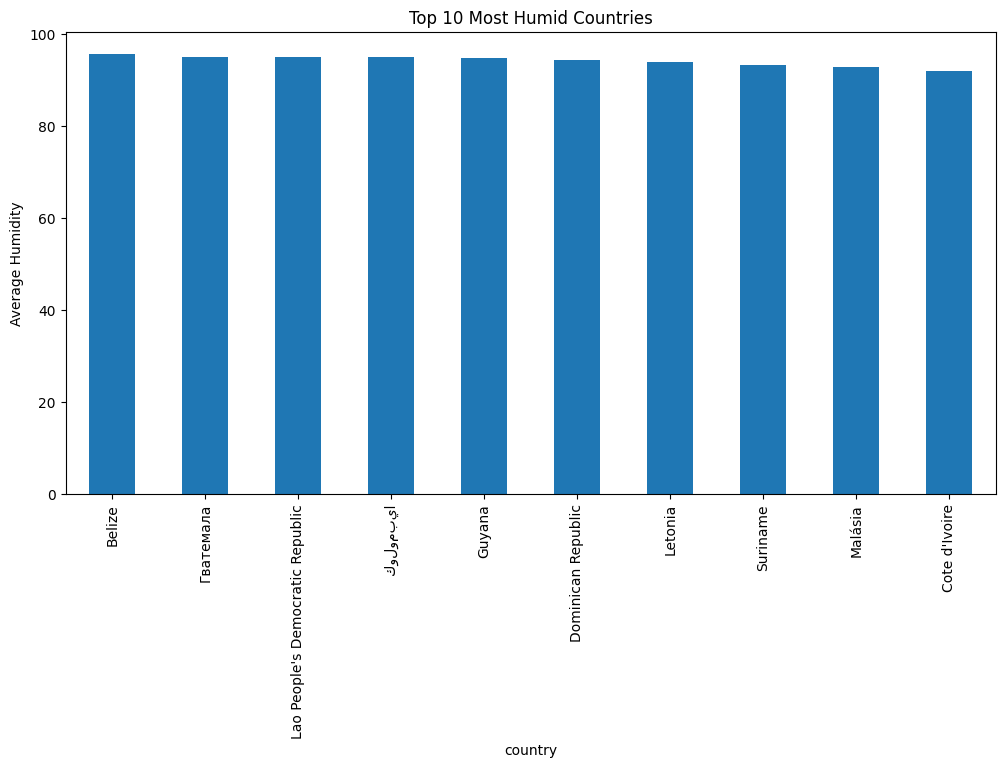

In [41]:
humid = (
    df.groupby('country')['humidity']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

humid.plot(kind='bar')

plt.title("Top 10 Most Humid Countries")

plt.ylabel("Average Humidity")

plt.savefig("../images/humidity_analysis.png")

plt.show()

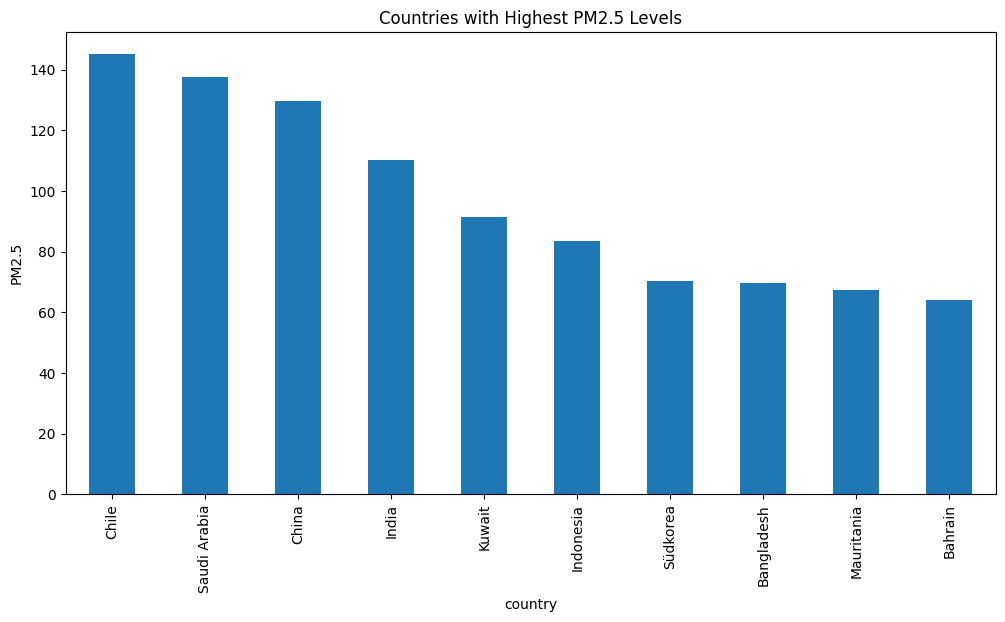

In [42]:
aqi = (
    df.groupby('country')['air_quality_PM2.5']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

aqi.plot(kind='bar')

plt.title("Countries with Highest PM2.5 Levels")

plt.ylabel("PM2.5")

plt.savefig("../images/aqi_analysis.png")

plt.show()

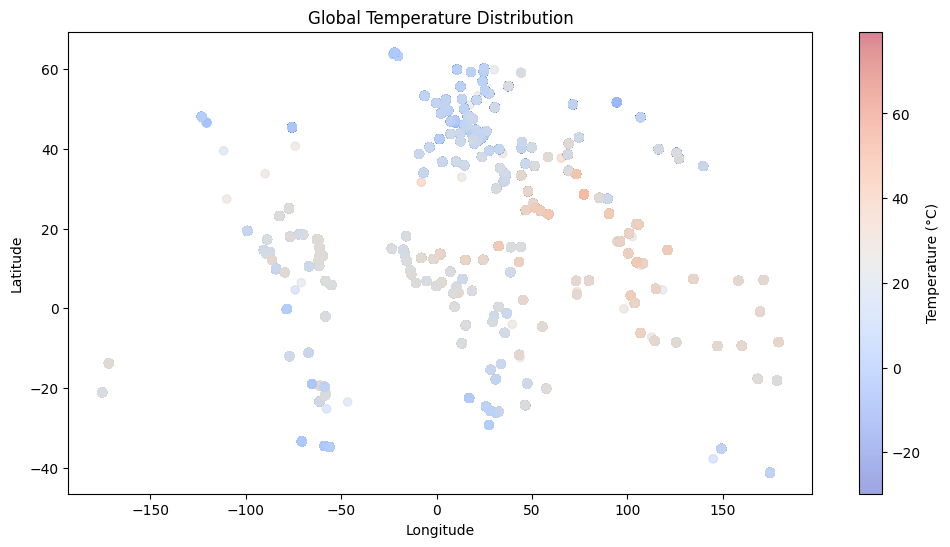

In [43]:
plt.figure(figsize=(12,6))

plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['temperature_celsius'],
    cmap='coolwarm',
    alpha=0.5
)

plt.colorbar(label='Temperature (°C)')

plt.title("Global Temperature Distribution")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.savefig("../images/spatial_analysis.png")

plt.show()

# Key Insights

## Major Findings

- Random Forest achieved the best forecasting performance.
- Temperature showed strong relationships with humidity, cloud cover, and feels-like temperature.
- Air quality indicators demonstrated environmental correlations with weather conditions.
- Several anomalous weather observations were detected using Isolation Forest.
- Spatial analysis revealed geographical temperature variations across regions.